# Imports

In [1]:
import os
from pathlib import Path
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pyfolio as pf
from pyfolio.plotting import plot_rolling_returns,plot_rolling_sharpe
from pyfolio.timeseries import forecast_cone_bootstrap

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
from backtester import BackTester

In [6]:
data_store=Path("../Prepared_Data_Store")

# BackTesting

## Trading Strategy-I:

### Here we will long the top returns and short the bottom returns values at a particular day as predicted by our Model-3

In [7]:
trading_strategy={
    "strategy":"returns_based",
    "values":{}
}

In [8]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.0,
    predictions_file=os.path.join(data_store,"factors.csv"),
    predictions_column_name="Model3_Factors",
    trading_strategy=trading_strategy
)

In [9]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-I...
[INFO]: Backtesting completed...


### Performance analysis using Pyfolio

#### Loading Benchmark Data

In [10]:
benchmark_data=pd.read_csv(
    os.path.join(data_store,"sp500_data.csv"),
    parse_dates=["date"],
    index_col=["date"]
)

In [11]:
benchmark_data=benchmark_data.sp500_returns.tz_localize("UTC")

#### Extracting information from Zipline Results

In [12]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe Ratio

In [13]:
LIVE_DATE="2016-02-24"

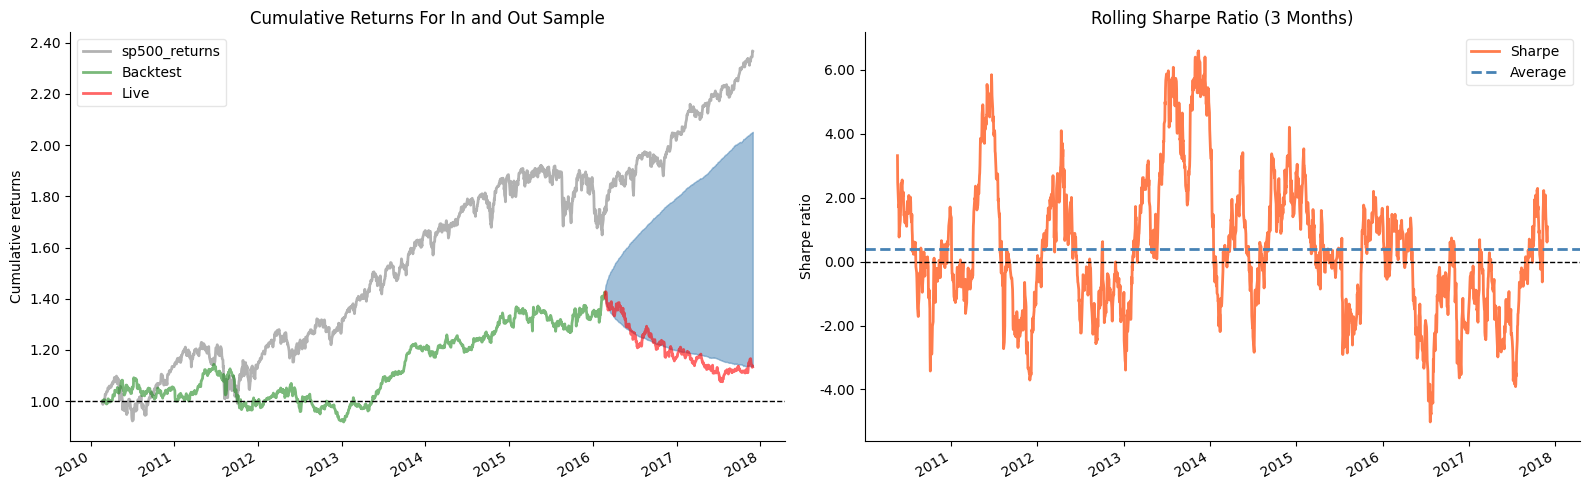

In [14]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns For In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,24.68,2016-02-26,2017-07-20,NaT,NaN
1,19.71,2011-06-22,2013-01-09,2013-10-03,597
2,8.43,2010-07-08,2011-01-10,2011-05-05,216
3,7.60,2015-05-07,2015-09-25,2015-11-24,144
4,6.93,2015-02-02,2015-04-13,2015-05-07,69


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.09%,-3.84%,3.61%
Fukushima,0.09%,-0.83%,0.86%
EZB IR Event,0.02%,-0.88%,2.30%
Flash Crash,0.44%,0.11%,0.74%
Apr14,-0.03%,-1.23%,0.95%
Oct14,0.04%,-1.32%,1.14%
Fall2015,-0.10%,-1.37%,1.42%
Recovery,-0.01%,-3.84%,3.61%
New Normal,0.02%,-3.14%,4.38%


Top 10 long positions of all time,max
sid,
BLDR,40.26%
NVDA,23.49%
NFLX,22.83%
EXPE,21.36%
VRTX,20.40%
NRG,19.96%
STLD,19.73%
BIIB,19.49%
MOH,18.65%


Top 10 short positions of all time,max
sid,
BLDR,-39.18%
NFLX,-28.57%
NVDA,-28.42%
VRTX,-25.14%
MOH,-23.89%
NRG,-23.77%
AMD,-16.84%
EXPE,-16.56%
TMUS,-16.37%


Top 10 positions of all time,max
sid,
BLDR,40.26%
NFLX,28.57%
NVDA,28.42%
VRTX,25.14%
MOH,23.89%
NRG,23.77%
EXPE,21.36%
STLD,19.73%
BIIB,19.49%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$835670.53,$-983365.84,$1819036.37
Gross profit,$23354925.25,$10904899.38,$12450025.87
Gross loss,$-22519254.72,$-11888265.22,$-10630989.50
Profit factor,$1.04,$0.92,$1.17
Avg. trade net profit,$11.11,$-27.49,$46.11
Avg. winning trade,$624.28,$637.49,$613.15
Avg. losing trade,$-606.45,$-646.98,$-566.74
Ratio Avg. Win:Avg. Loss,$1.03,$0.99,$1.08
Largest winning trade,$131773.17,$131773.17,$106592.96
Largest losing trade,$-43399.59,$-43399.59,$-34058.58


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 22:21:01.438105747,1 days 15:48:26.391377285,2 days 04:16:56.278319941
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,195 days 01:00:00,195 days 01:00:00,181 days 23:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.05%,0.06%,0.05%
Avg returns losing,-0.05%,-0.06%,-0.05%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.03%,0.03%,0.03%
Median returns losing,-0.03%,-0.03%,-0.02%
Largest winning trade,11.63%,11.63%,10.65%
Largest losing trade,-3.33%,-3.33%,-2.57%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,0.01%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.01%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,0.01%,0.01%,0.00%,-0.00%,0.01%,-0.00%,0.00%,-0.00%,0.00%,0.00%,0.01%,0.01%,-0.00%,0.00%,0.01%,0.01%,-0.00%,-0.01%,-0.00%,0.01%,0.01%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,0.00%,0.00%,-0.00%,-0.01%,0.00%,0.00%,0.00%,0.02%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,-0.00%,0.01%,0.01%,-0.01%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.00%,0.01%,0.00%,-0.01%,-0.00%,0.01%,0.00%,0.01%,-0.00%,-0.03%,-0.01%,0.00%,0.01%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.01%,0.00%,-0.01%,-0.00%,0.01%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.09%,-0.00%,-0.01%,-0.01%,-0.00%,0.01%,0.01%,0.00%,-0.01%,-0.00%,-0.01%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.01%,-0.00%,-0.01%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.01%,0.00%,-0.00%,0.00%,-0.01%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.01%,0.01%,-0.01%,0.01%,0.01%,-0.01%,0.01%,0.02%,0.00%,0.01%,0.00%,0.00%,0.00%,0.01%,0.00%,0.00%,0.01%,0.01%,0.00%,-0.00%,0.01%,-0.01%,0.00%,-0.00%,-0.00%,0.00%,0.01%,0.01%,0.00%,-0.00%,-0.02%,0.00%,0.00%,-0.01%,0.00%,0.01%,-0.01%,-0.00%,-0.01%,-0.00%,-0.00%,-0.00%,0.02%,-0.00%,0.00%,0.03%,-0.00%,0.00%,0.00%,0.00%,0.00%,0.01%,0.01%,0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.01%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,0.01%,-0.01%,0.01%,0.01%,0.00%,-0.01%,-0.00%,0.00%,0.00%,-0.01%,0.00%,0.01%,0.00%,-0.00%,-0.01%,0.01%,-0.00%,0.01%,-0.00%,0.01%,-0.00%,-0.01%,-0.00%,-0.00%,0.01%,0.00%,0.06%,-0.00%,0.00%,-0.01%,0.00%,0.00%,-0.01%,0.01%,0.00%,-0.00%,0.02%,-0.00%,-0.01%,-0.01%,-0.01%,0.00%,-0.00%,-0.00%,0.01%,-0.01%,0.00%,-0.01%,0.01%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.01%,0.00%,-0.02%,-0.01%,-0.00%,0.01%,-0.00%,-0.00%,-0.00%,-0.01%,-0.00%,0.00%,-0.00%,0.00%,-0.02%,-0.00%,0.01%,-0.00%,-0.00%,-0.00%,0.01%,-0.01%,0.00%,0.00%,-0.01%,-0.00%,0.01%,0.00%,0.00%,0.00%,-0.01%,0.01%,-0.01%,0.00%,-0.00%,-0.00%,-0.00%,-0.01%,0.00%,0.01%,-0.00%,0.01%,0.01%,-0.00%,0.01%,0.00%,0.01%,0.01%,0.00%,-0.01%,0.00%,0.01%,0.00%,-0.00%,-0.00%,-0.00%,0.01%,0.00%,-0.00%,0.00%,-0.01%,0.01%,0.00%,-0.01%,-0.01%,-0.01%,0.00%,0.00%,0.02%,-0.01%,-0.00%,0.00%,0.01%,-0.00%,0.01%,-0.00%,0.00%,0.00%,0.00%,-0.01%,-0.00%,0.01%,-0.01%,-0.01%,-0.00%,-0.00%,0.01%,0.01%,0.01%,0.01%,-0.01%,-0.00%,-0.01%,0.03%,0.00%,-0.01%,-0.00%,0.01%,-0.01%,-0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%
Avg returns 

Profitability (PnL / PnL total) per name,
symbol,
MSI,52.17%
DUK,13.45%
BLDR,9.28%
WMB,7.73%
DECK,6.58%
NKE,6.37%
PWR,6.32%
TER,5.96%
GIS,5.94%


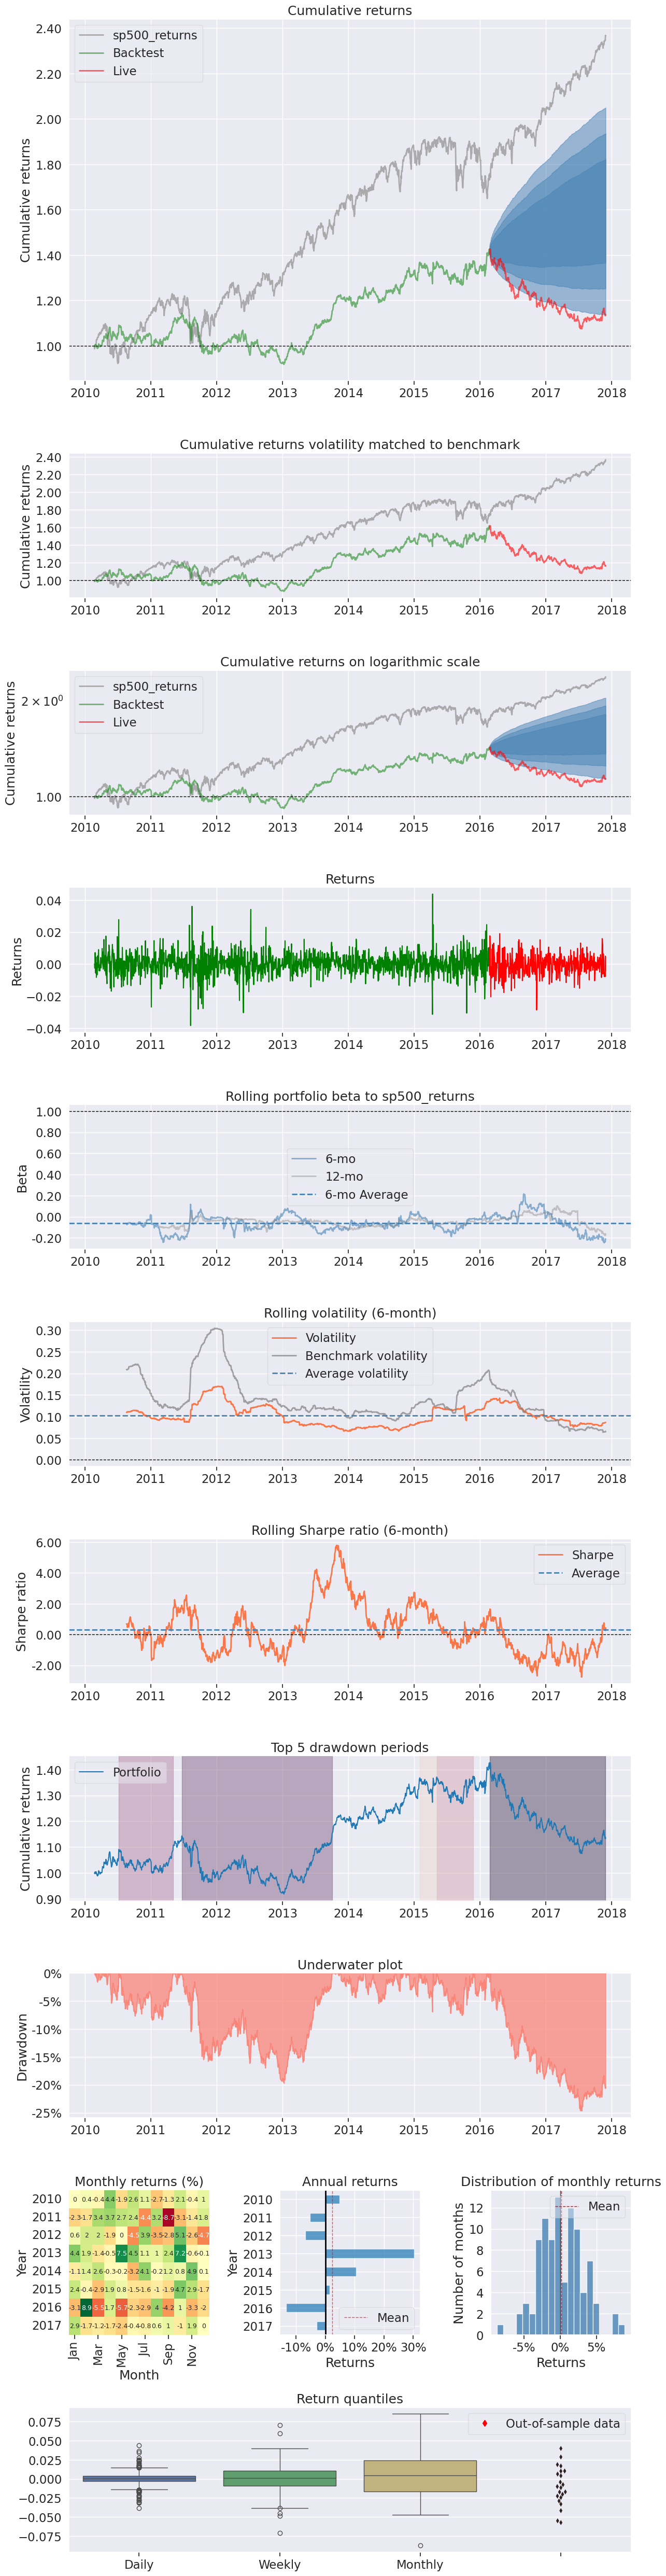

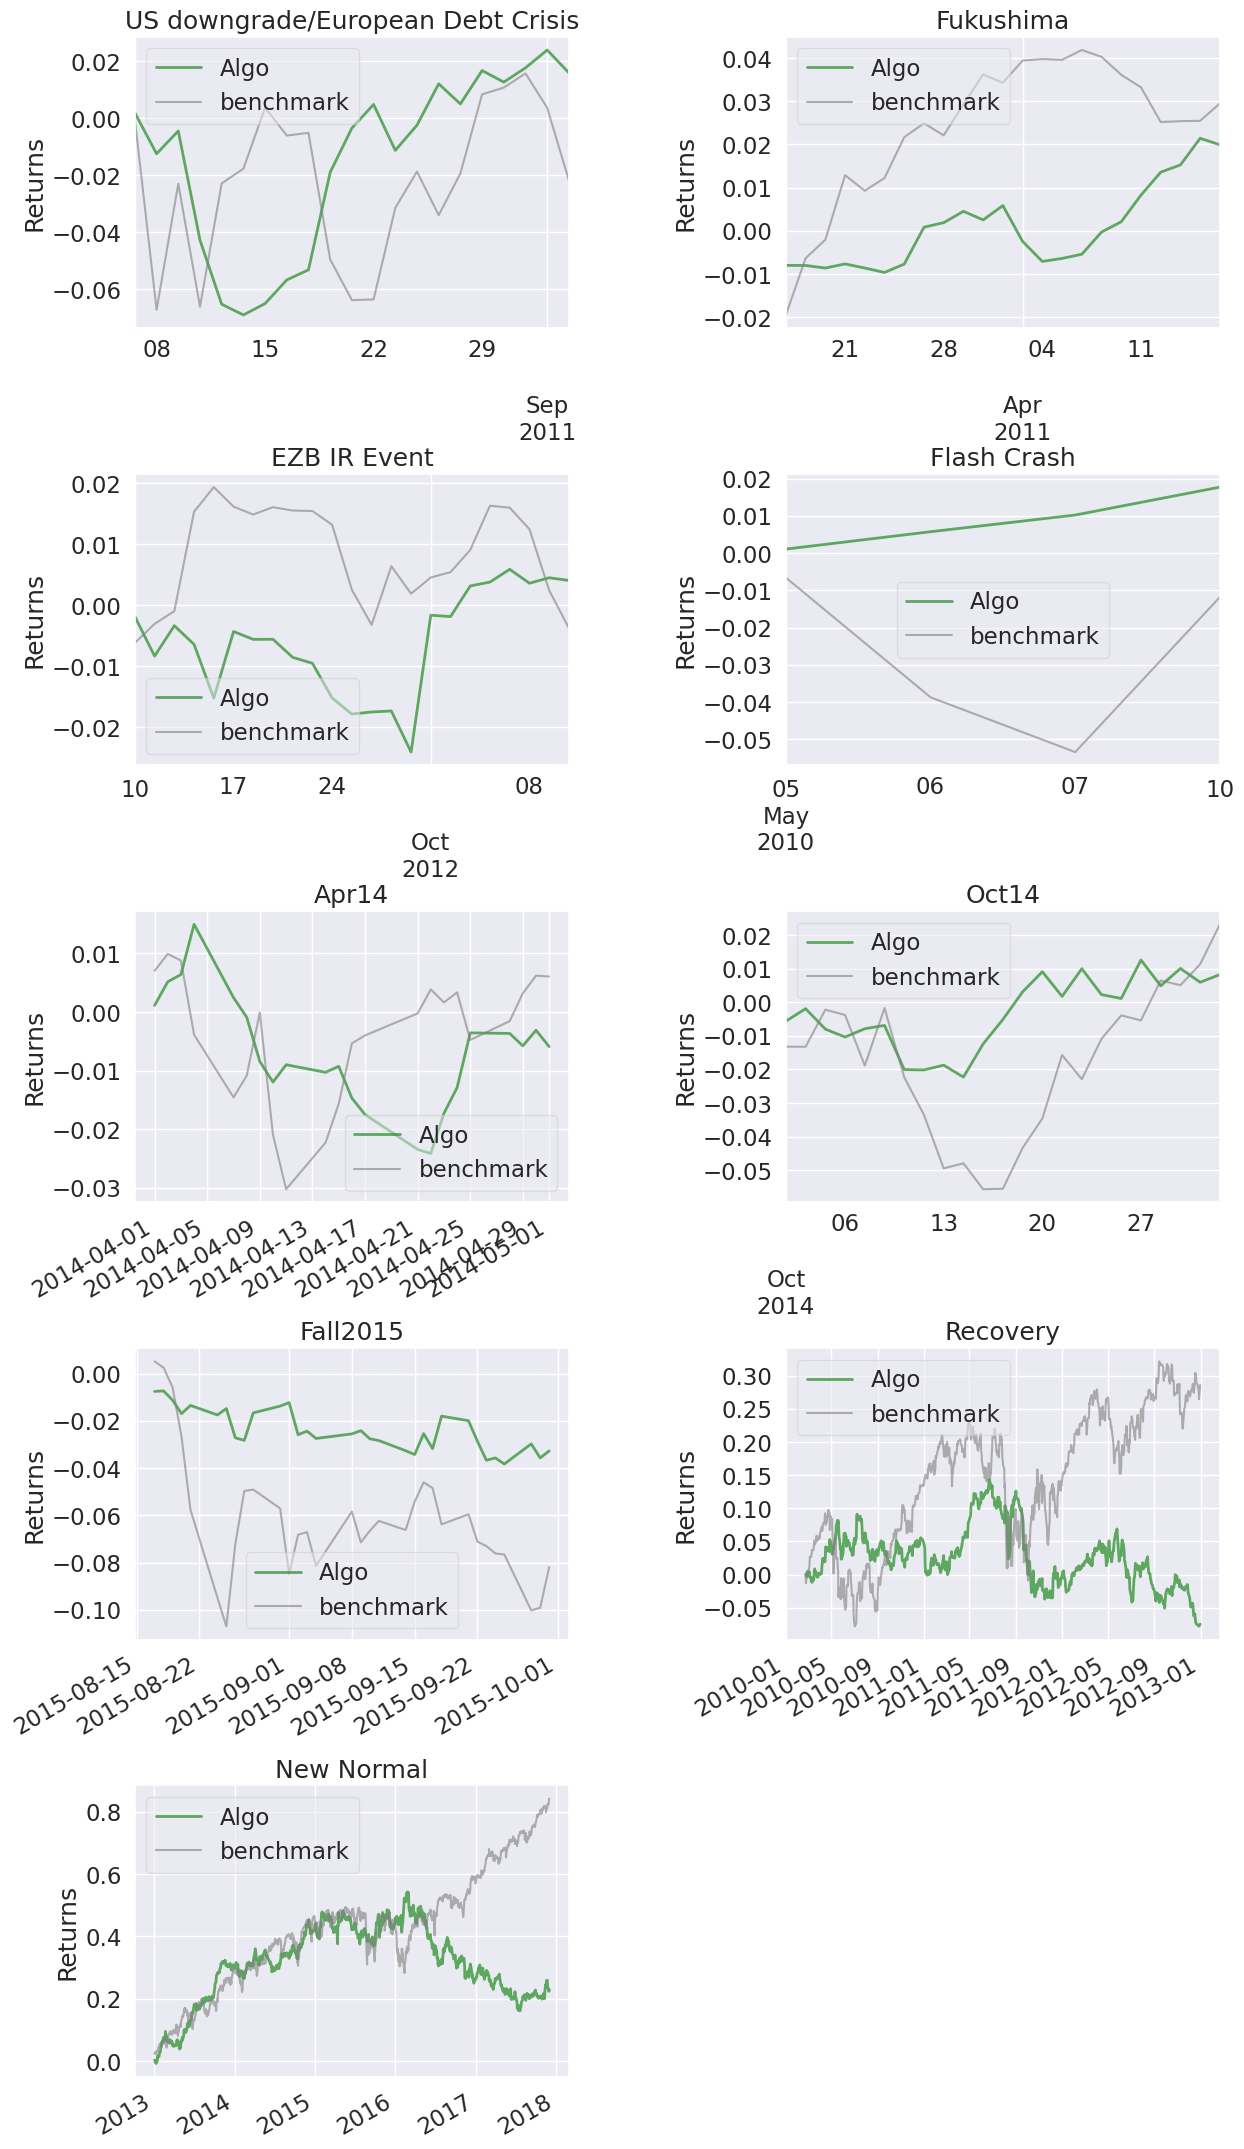

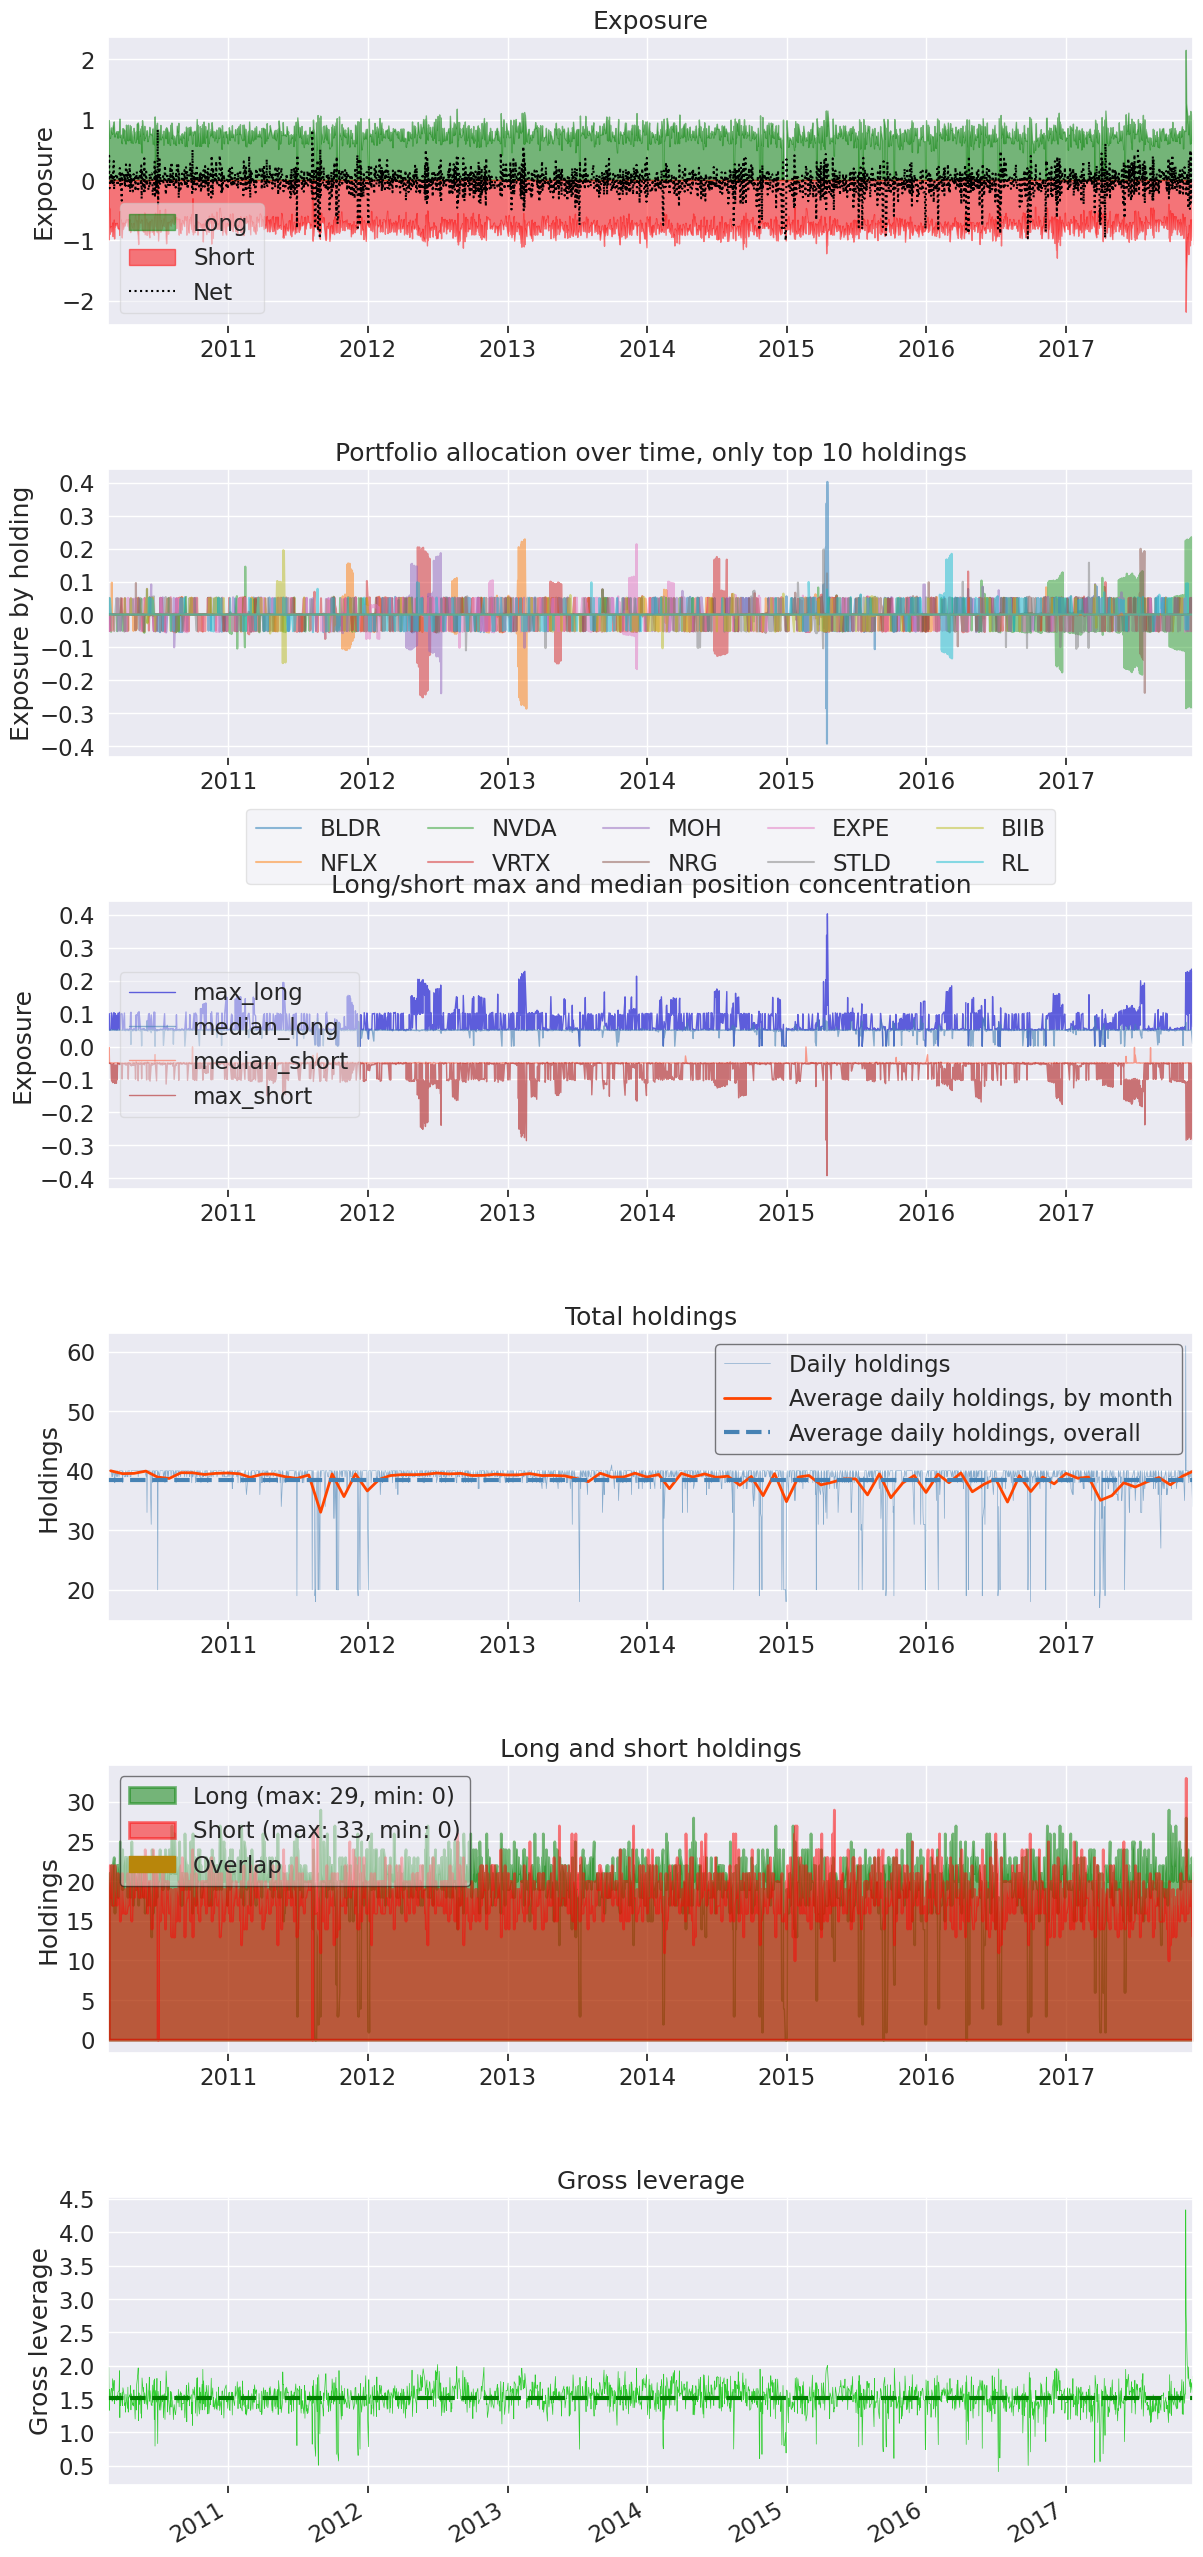

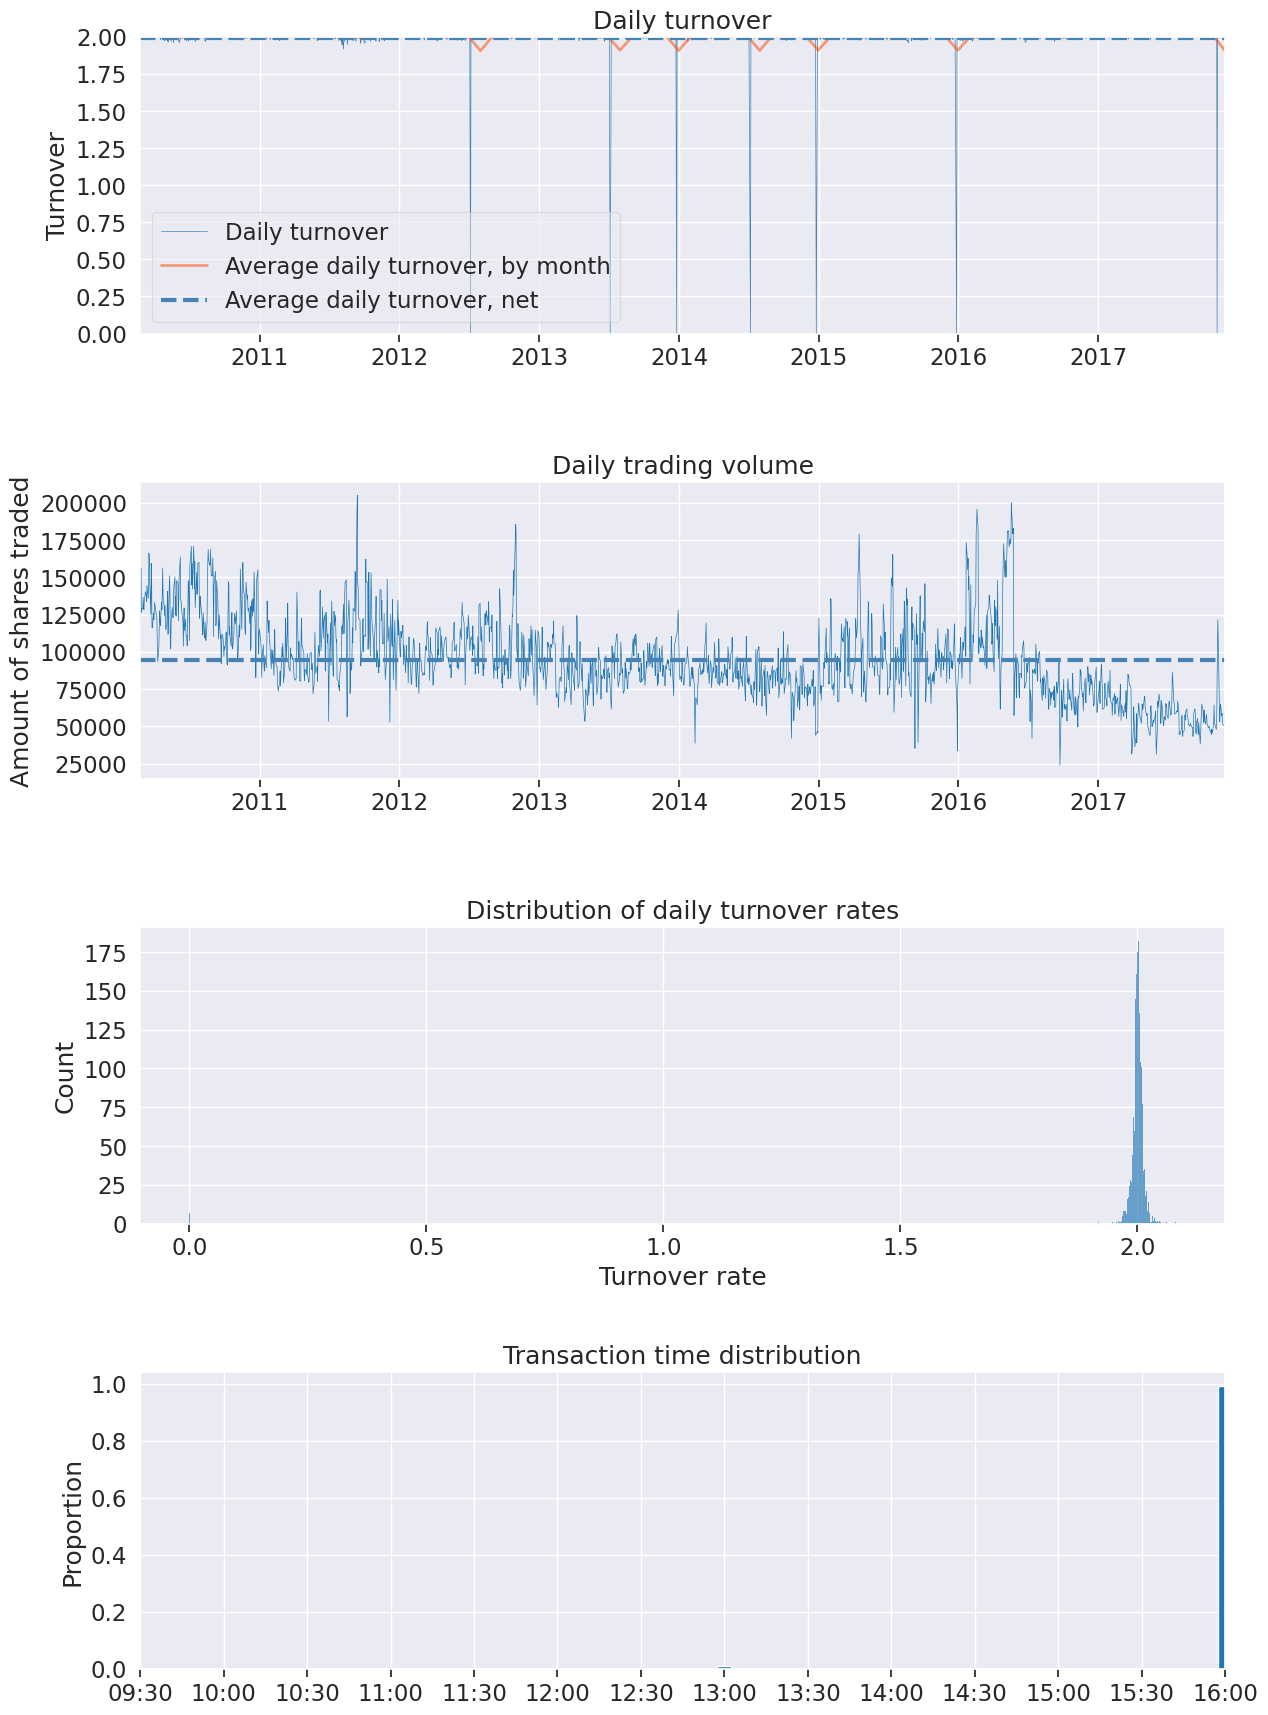

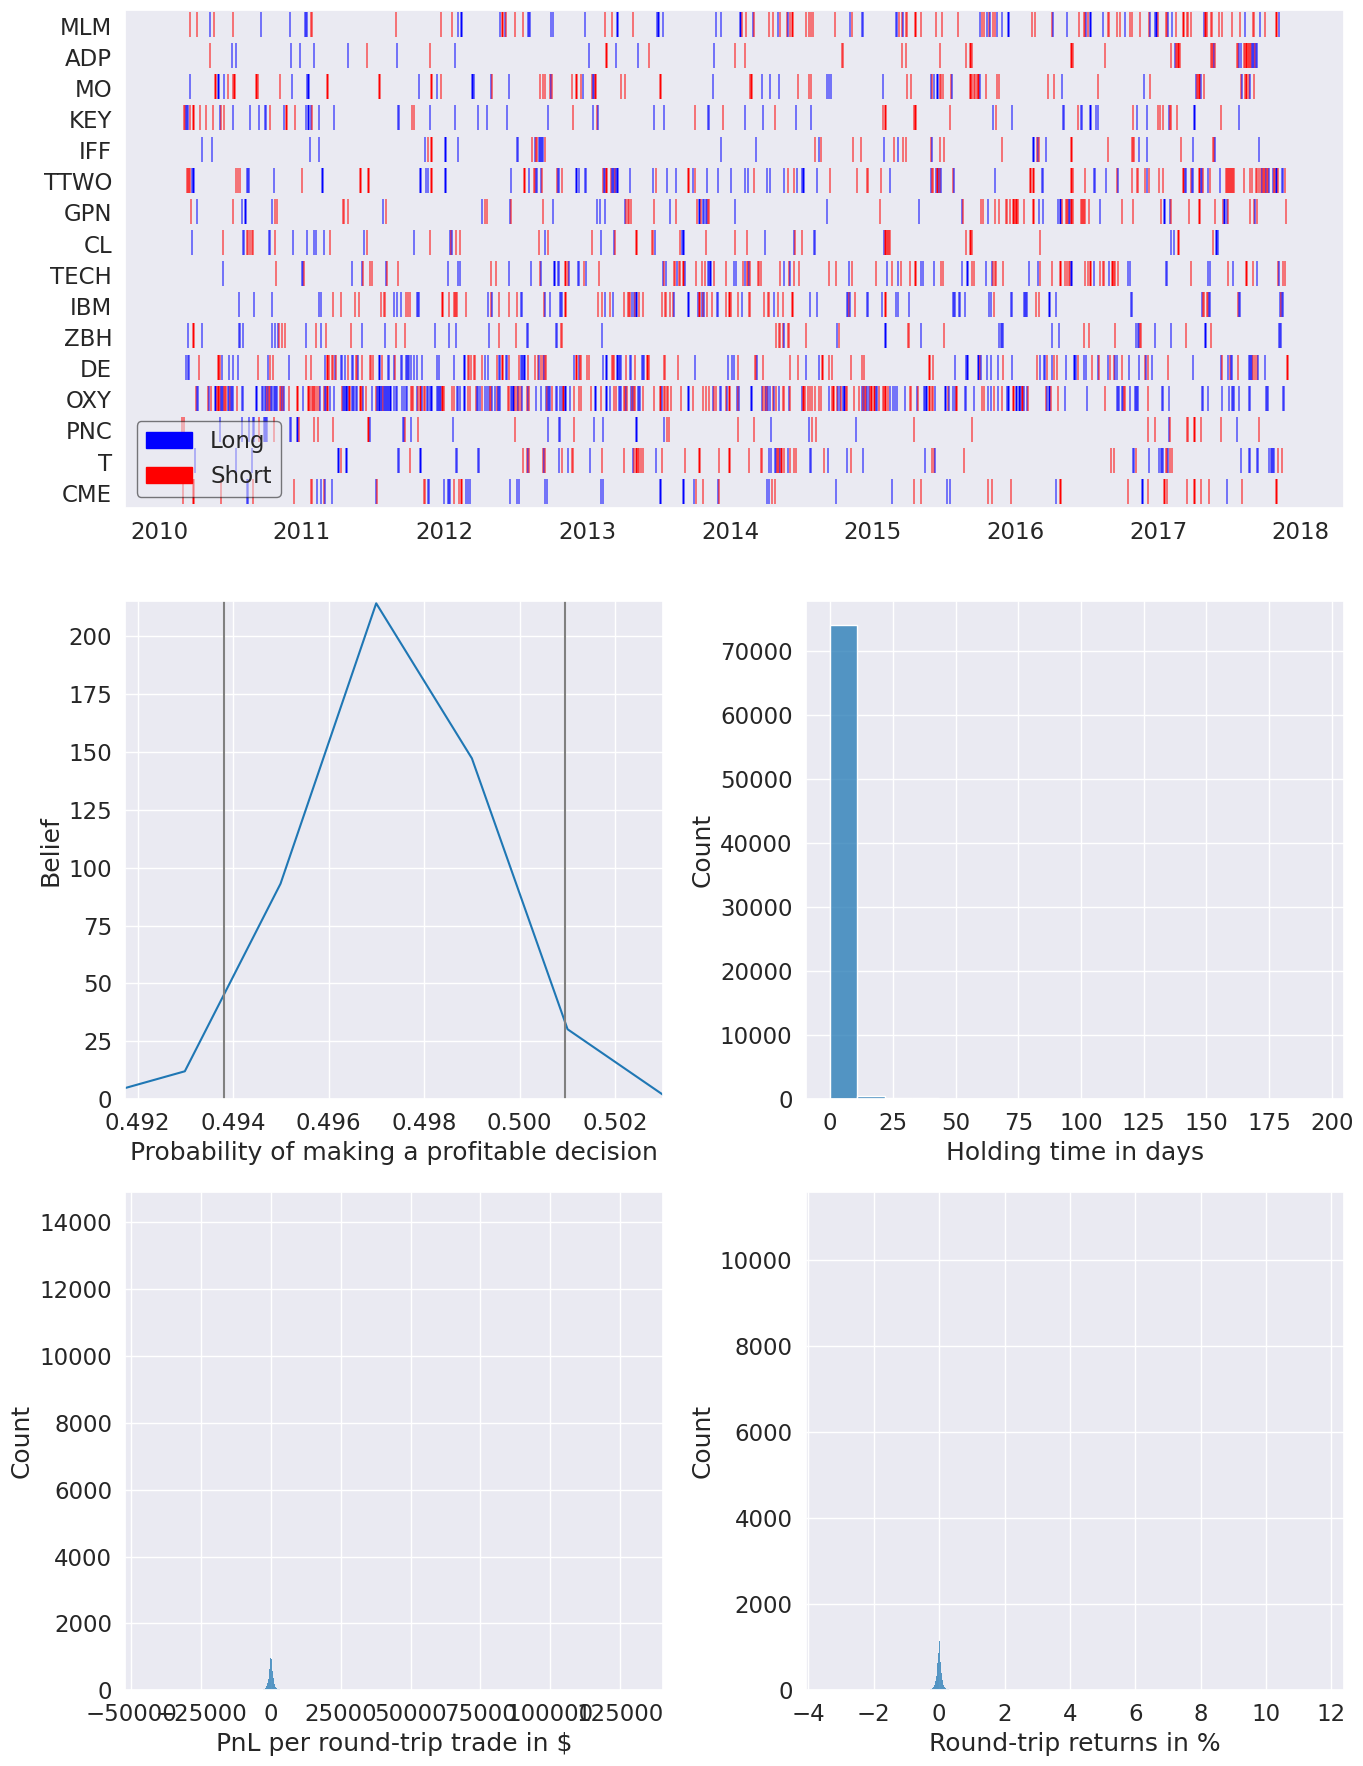

In [15]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)

## Trading Strategy-II:

### As per the Signal Evaluation of the Model-3 Factors, we will long and short predictions in quantiles 4 and 5 respectively.

In [16]:
trading_strategy={
    "strategy":"quantile_based",
    "values":{
        "quantile_long":4,
        "quantile_short":5
}

}

In [17]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.0,
    predictions_file=os.path.join(data_store,"factors.csv"),
    predictions_column_name="Model3_Factors",
    trading_strategy=trading_strategy
)

In [18]:
results=backtester.run_backtesting()

[INFO]: Model predictions loaded...
[INFO]: Missing Date Values added in Model Predictions...
[INFO]: Model Data Loader created...
[INFO]: Backtesting started for trading strategy-II...
[INFO]: Backtesting completed...


### Performance analysis using Pyfolio

#### Extracting information from Zipline Results

In [19]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe Ratio

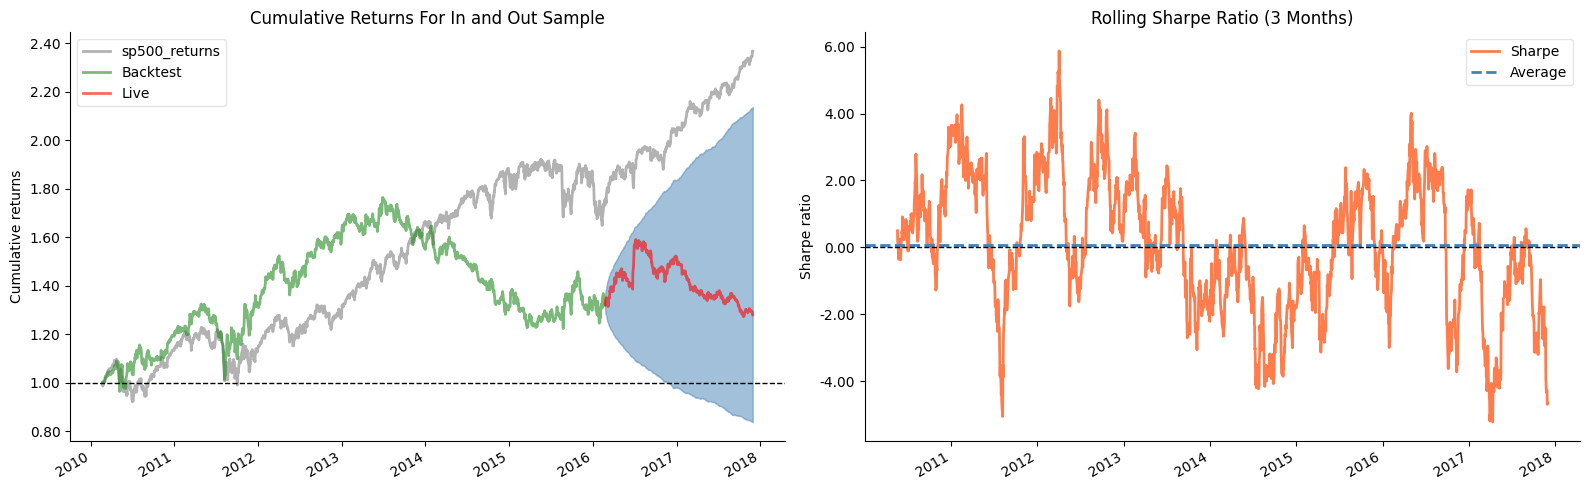

In [20]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns For In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,30.65,2013-06-28,2015-08-25,NaT,NaN
1,23.45,2011-04-28,2011-08-08,2011-12-15,166
2,11.52,2010-04-23,2010-05-07,2010-07-13,58
3,10.59,2012-04-02,2012-05-18,2012-08-06,91
4,8.69,2010-08-02,2010-08-26,2010-12-02,89


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.33%,-6.90%,5.69%
Fukushima,0.12%,-1.27%,2.11%
EZB IR Event,0.02%,-1.57%,1.38%
Flash Crash,-0.10%,-2.52%,4.70%
Apr14,0.03%,-1.23%,1.26%
Oct14,-0.19%,-1.63%,1.49%
Fall2015,0.15%,-4.56%,3.48%
Recovery,0.07%,-6.90%,5.69%
New Normal,-0.01%,-4.56%,4.83%


Top 10 long positions of all time,max
sid,
GPN,19.42%
AFL,18.15%
PNR,16.02%
PG,15.53%
BAC,15.23%
ES,15.09%
ROST,15.08%
MTB,14.99%
CSCO,14.98%


Top 10 short positions of all time,max
sid,
MAS,-18.72%
GOOGL,-15.62%
IP,-14.78%
VZ,-14.72%
NEM,-14.71%
REG,-14.59%
WAT,-14.44%
HSY,-14.42%
MO,-14.21%


Top 10 positions of all time,max
sid,
GPN,19.42%
MAS,18.72%
AFL,18.15%
PNR,16.02%
GOOGL,15.62%
PG,15.53%
BAC,15.23%
ES,15.09%
ROST,15.08%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$298918.27,$-902503.37,$1201421.64
Gross profit,$16259973.35,$7116329.56,$9143643.79
Gross loss,$-15961055.08,$-8018832.93,$-7942222.15
Profit factor,$1.02,$0.89,$1.15
Avg. trade net profit,$7.26,$-45.78,$56.03
Avg. winning trade,$797.60,$768.34,$821.97
Avg. losing trade,$-782.52,$-779.81,$-785.27
Ratio Avg. Win:Avg. Loss,$1.02,$0.99,$1.05
Largest winning trade,$60828.67,$60828.67,$16703.15
Largest losing trade,$-55839.94,$-25693.56,$-55839.94


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 13:23:12.662034112,1 days 16:44:07.864512529,1 days 10:18:30.015995150
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,164 days 00:00:00,164 days 00:00:00,5 days 03:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 20:59:59


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.06%,0.06%,0.06%
Avg returns losing,-0.06%,-0.06%,-0.06%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.04%,0.04%,0.04%
Median returns losing,-0.04%,-0.04%,-0.04%
Largest winning trade,4.03%,4.03%,1.29%
Largest losing trade,-3.25%,-1.80%,-3.25%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,0.00%,0.00%,-0.01%,-0.00%,-0.00%,0.00%,0.02%,-0.00%,-0.00%,-0.00%,0.01%,-0.00%,-0.01%,0.00%,0.00%,0.01%,-0.01%,0.02%,-0.01%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.01%,-0.01%,-0.00%,0.01%,-0.00%,0.00%,0.01%,0.01%,-0.00%,-0.00%,0.00%,-0.00%,0.03%,0.00%,-0.01%,-0.02%,0.01%,-0.00%,-0.00%,0.01%,0.00%,0.01%,0.00%,0.01%,-0.00%,0.01%,0.01%,-0.00%,0.01%,0.01%,0.01%,-0.01%,0.00%,0.00%,0.00%,0.01%,0.00%,-0.01%,-0.01%,-0.00%,0.00%,0.00%,0.00%,0.00%,-0.01%,-0.00%,-0.00%,0.01%,0.01%,-0.00%,-0.01%,0.00%,0.00%,0.01%,-0.00%,-0.01%,-0.00%,0.00%,0.01%,0.00%,0.00%,-0.01%,0.00%,0.01%,0.01%,-0.00%,-0.00%,-0.02%,0.01%,0.01%,0.00%,-0.01%,0.01%,0.01%,0.01%,-0.00%,-0.00%,-0.00%,-0.02%,-0.02%,-0.00%,0.01%,-0.00%,-0.00%,0.00%,-0.01%,0.00%,0.01%,-0.01%,0.01%,0.00%,-0.01%,0.01%,-0.00%,-0.00%,-0.00%,0.03%,-0.00%,-0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.01%,-0.01%,0.00%,0.00%,0.00%,-0.01%,0.01%,-0.02%,0.01%,-0.00%,0.01%,-0.00%,-0.02%,0.01%,-0.01%,0.01%,0.00%,-0.01%,0.00%,-0.00%,-0.00%,0.01%,-0.01%,-0.00%,-0.00%,-0.00%,0.02%,-0.00%,0.01%,0.01%,0.01%,0.00%,0.01%,0.01%,0.01%,0.00%,-0.01%,-0.00%,-0.00%,0.01%,-0.00%,-0.01%,-0.00%,-0.00%,0.02%,0.01%,0.01%,0.01%,-0.01%,0.01%,0.00%,0.02%,0.00%,0.01%,0.01%,-0.00%,0.01%,-0.01%,-0.00%,0.01%,0.01%,-0.00%,0.01%,0.01%,-0.00%,0.01%,0.01%,0.00%,-0.00%,-0.00%,-0.00%,-0.01%,-0.00%,0.01%,-0.01%,0.00%,-0.01%,0.00%,0.02%,-0.01%,-0.01%,0.00%,-0.01%,0.01%,0.01%,0.00%,-0.00%,-0.02%,0.00%,0.03%,-0.01%,-0.00%,-0.01%,-0.01%,-0.00%,0.01%,-0.02%,0.00%,-0.02%,0.01%,-0.00%,-0.01%,0.01%,-0.00%,0.01%,-0.00%,0.01%,0.01%,-0.01%,0.00%,0.02%,-0.00%,-0.01%,0.00%,0.01%,-0.02%,0.00%,-0.00%,-0.00%,-0.01%,0.01%,-0.00%,0.01%,-0.00%,0.00%,0.02%,-0.00%,0.01%,0.00%,-0.01%,-0.02%,-0.01%,0.00%,0.00%,0.01%,0.00%,0.01%,-0.00%,-0.00%,0.00%,-0.01%,-0.00%,-0.01%,0.00%,-0.00%,-0.00%,0.01%,-0.01%,-0.02%,0.00%,0.00%,0.00%,0.00%,-0.00%,-0.02%,-0.00%,-0.01%,0.01%,-0.01%,-0.01%,0.00%,0.01%,-0.00%,-0.00%,0.01%,-0.01%,-0.00%,-0.01%,0.01%,0.01%,0.00%,0.01%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,0.01%,0.01%,0.00%,0.02%,-0.01%,0.00%,-0.00%,-0.00%,0.01%,-0.01%,0.00%,0.01%,0.00%,0.02%,0.01%,-0.01%,0.02%,-0.01%,-0.00%,-0.00%,0.01%,0.00%,-0.01%,-0.00%,-0.01%,0.00%,0.02%,0.00%,0.01%,0.00%,-0.01%,0.00%,-0.01%,0.00%,0.01%,0.00%,0.00%,-0.00%,-0.01%,-0.01%,0.01%,-0.01%,-0.01%,0.01%,0.00%,0.00%,-0.00%,-0.00%,0.00%,0.01%,-0.00%,-0.00%,0.01%,0.00%,0.02%,-0.01%,0.00%,0.01%,0.01%,-0.01%,-0.01%,0.00%,-0.00%,0.01%,0.00%,0.01%,0.02%
Avg returns wi

Profitability (PnL / PnL total) per name,
symbol,
BBY,12.66%
WMB,12.02%
ETN,11.42%
ADSK,11.24%
LYV,10.71%
TEL,9.90%
AMAT,9.83%
HBAN,9.75%
IP,9.58%


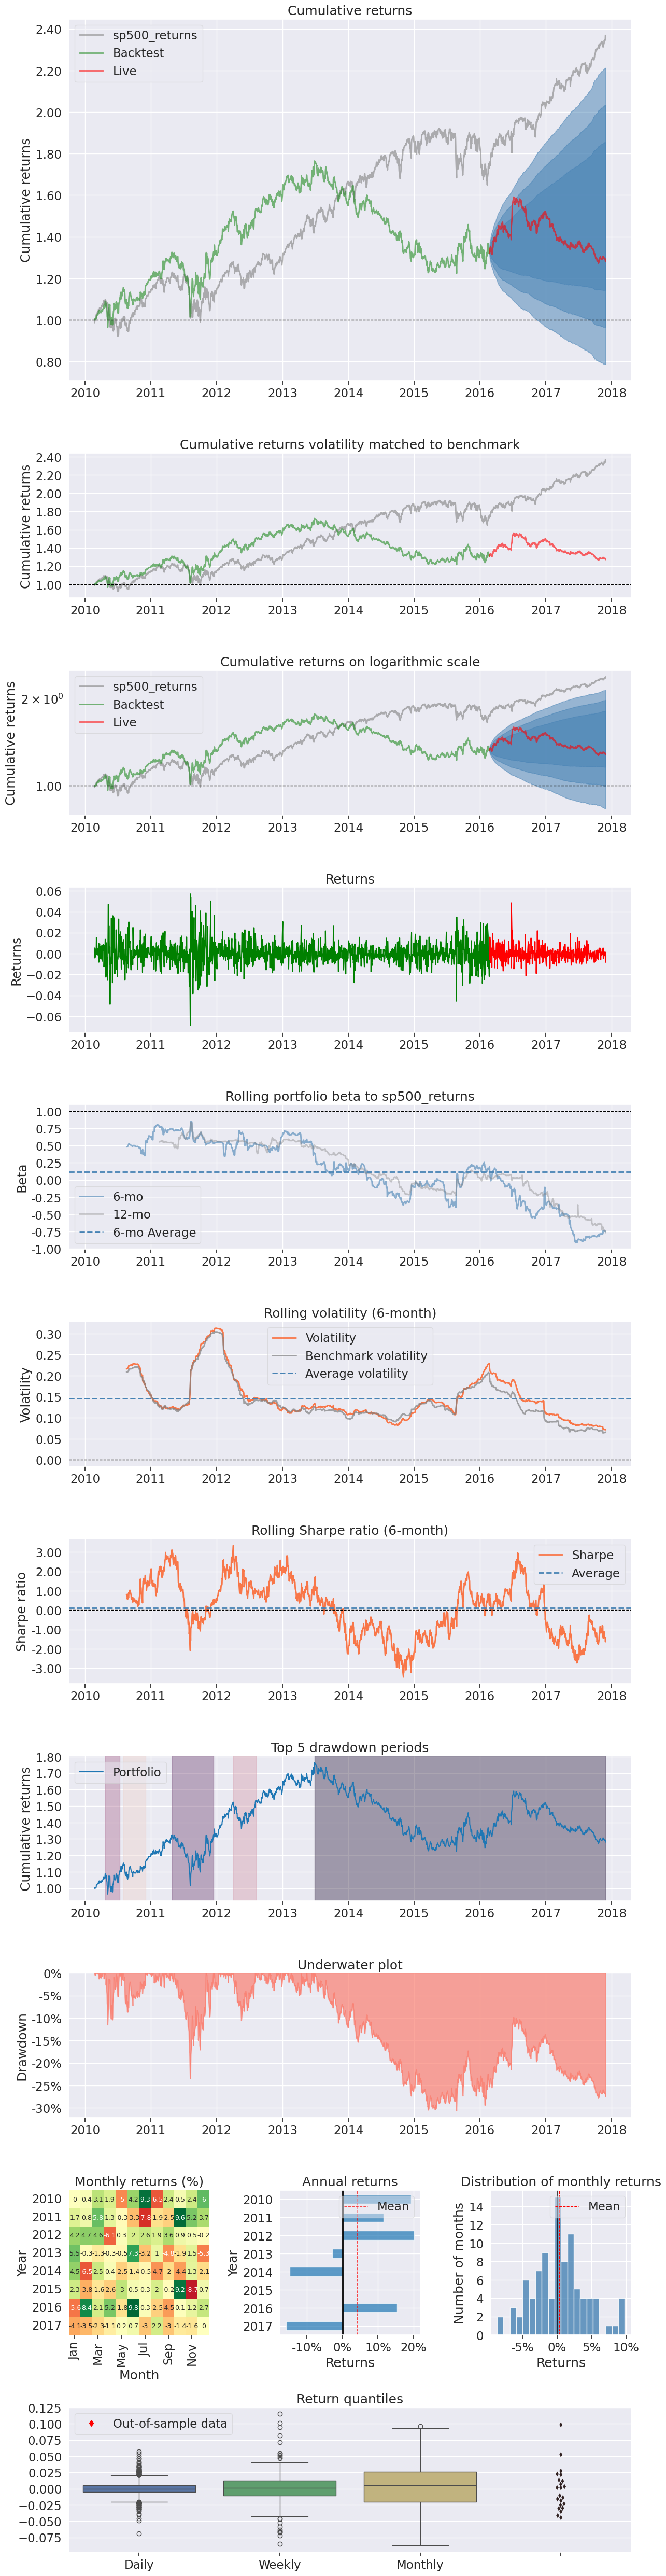

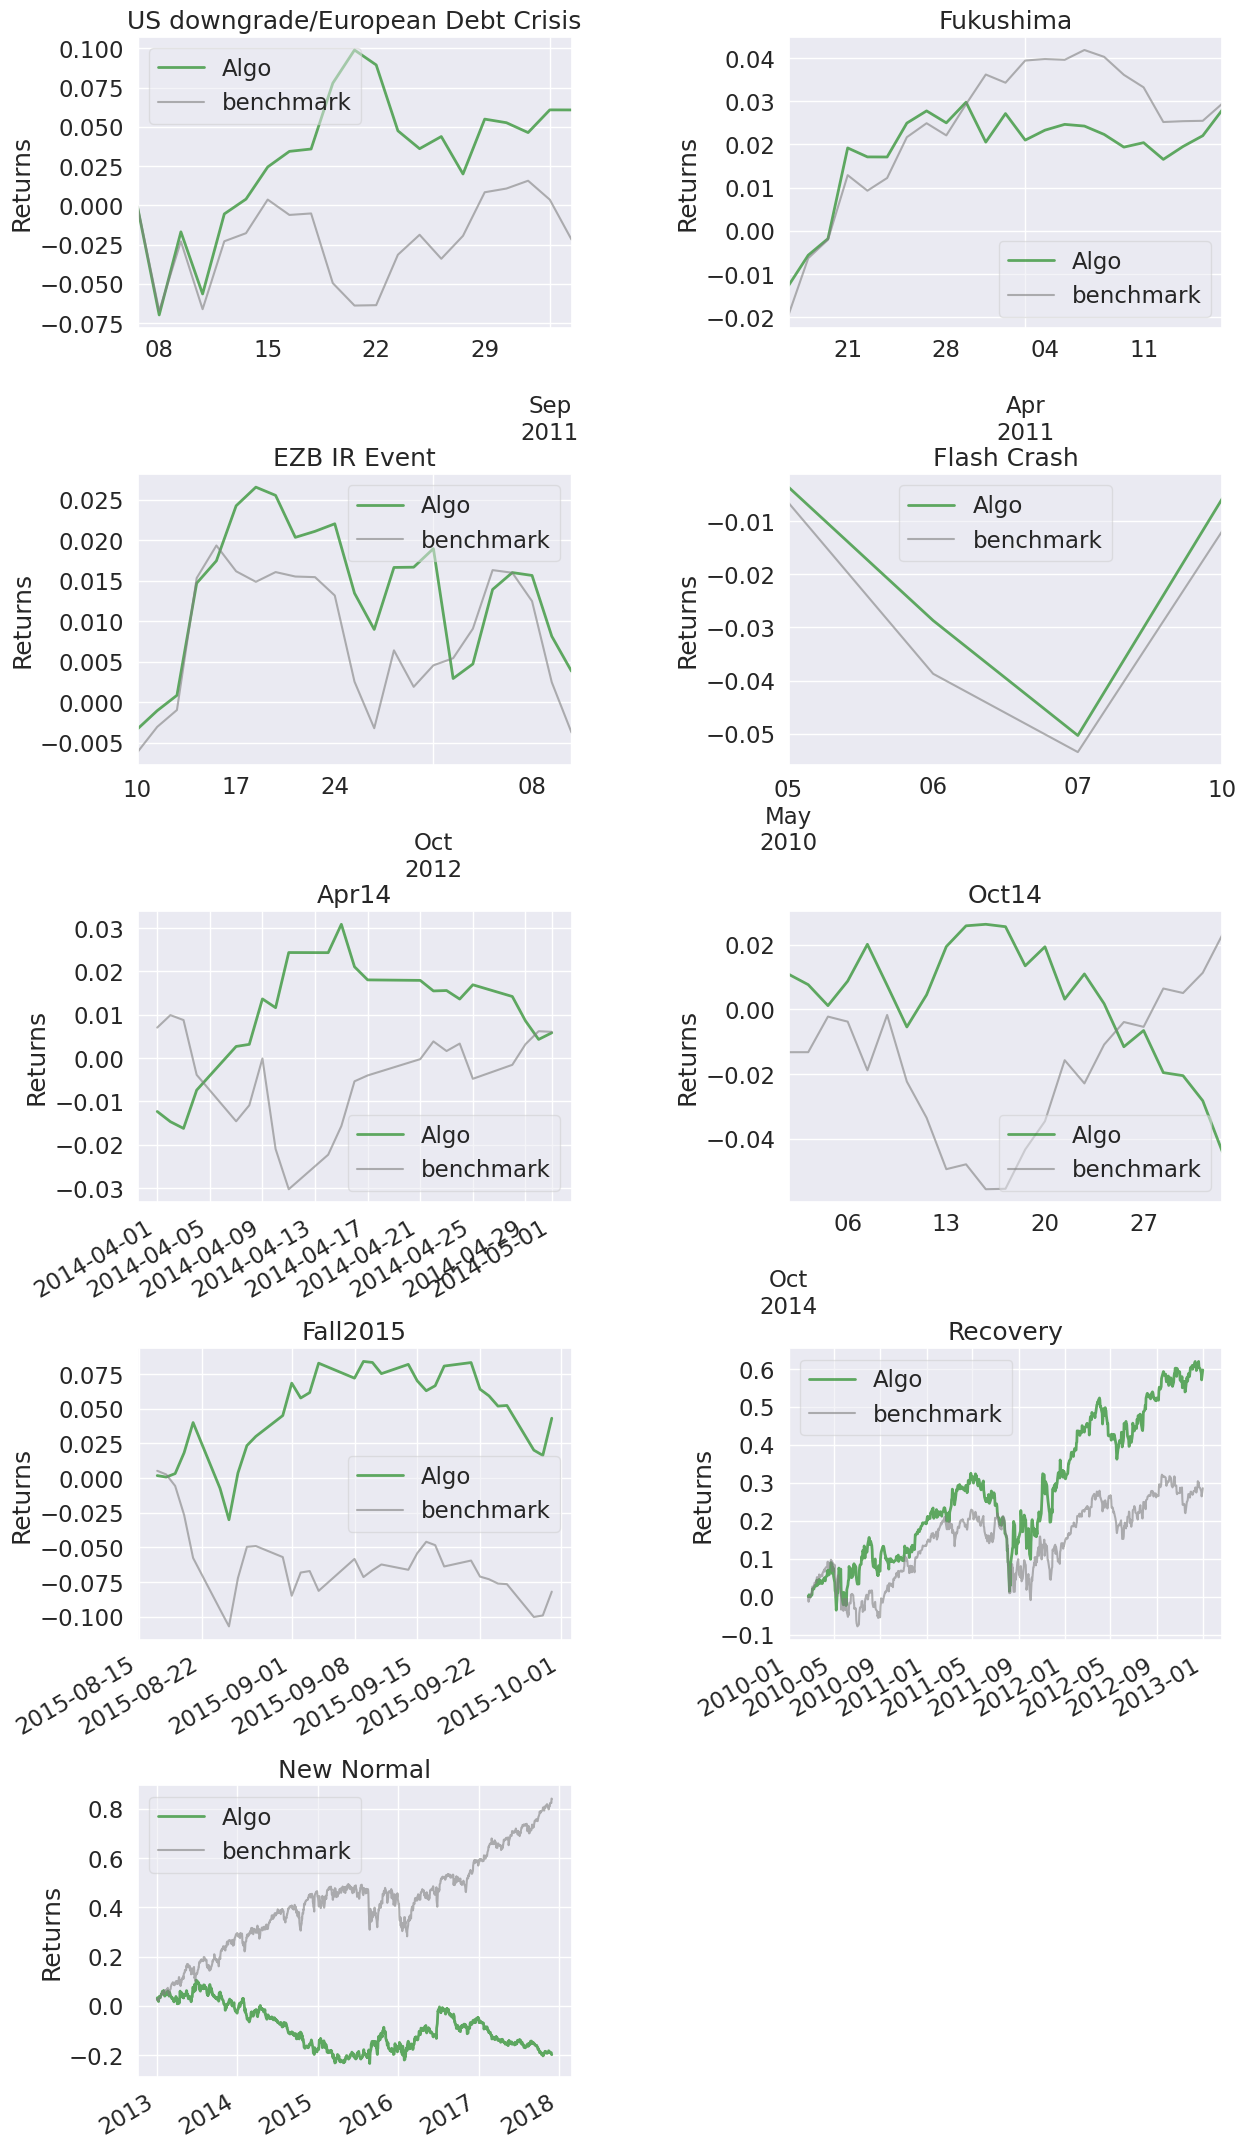

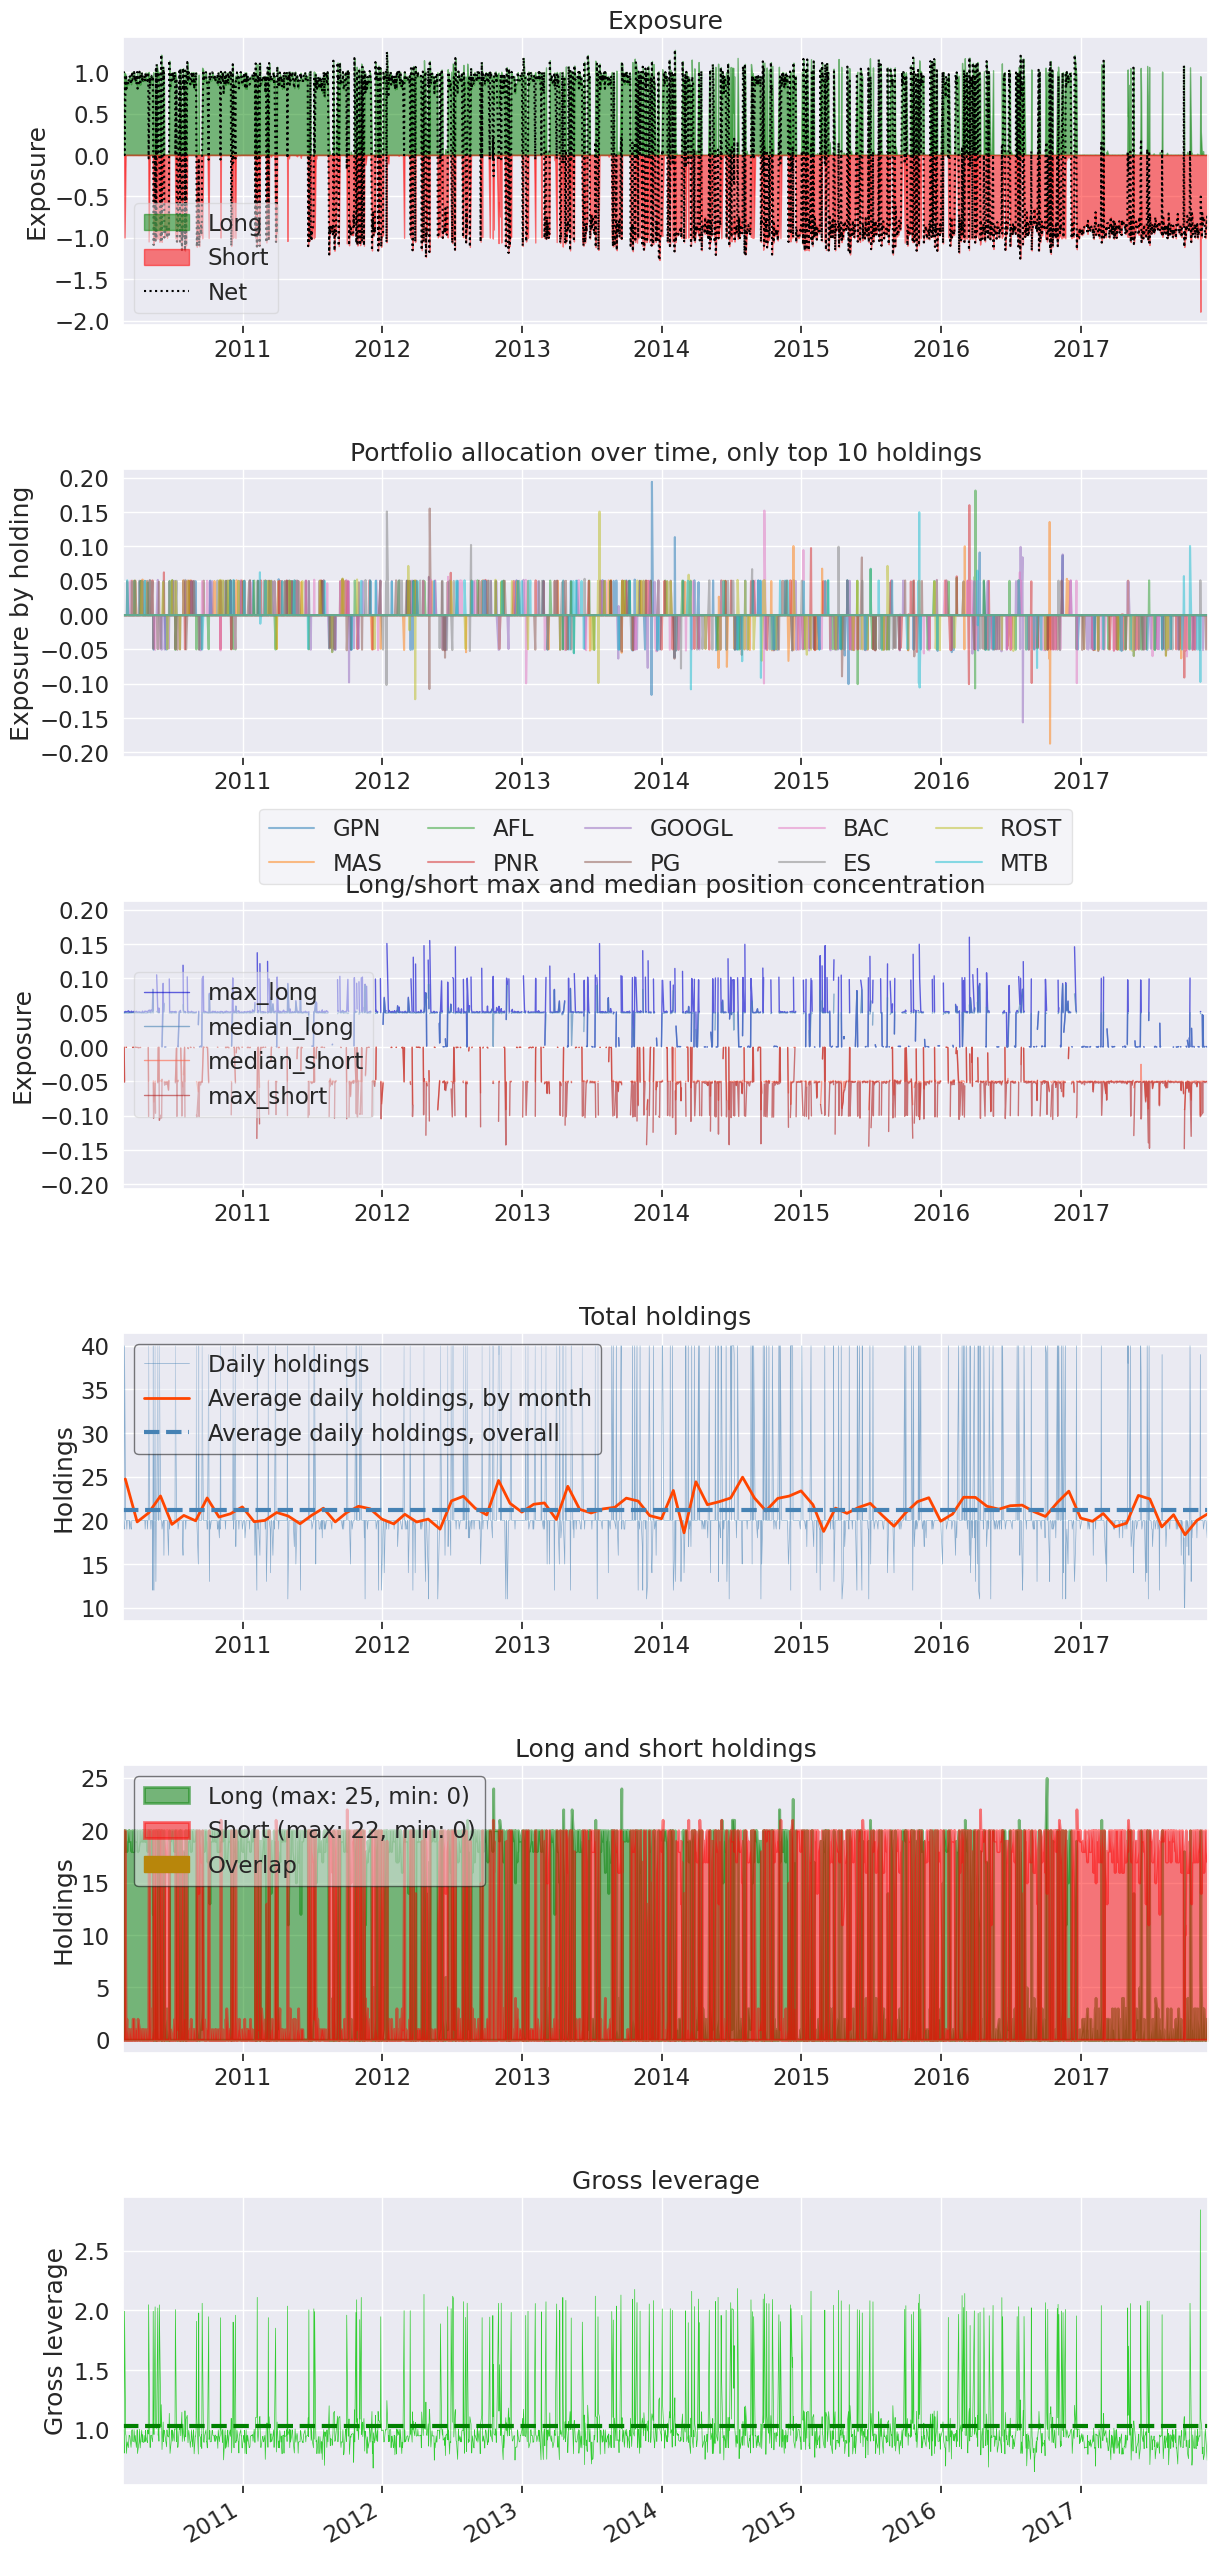

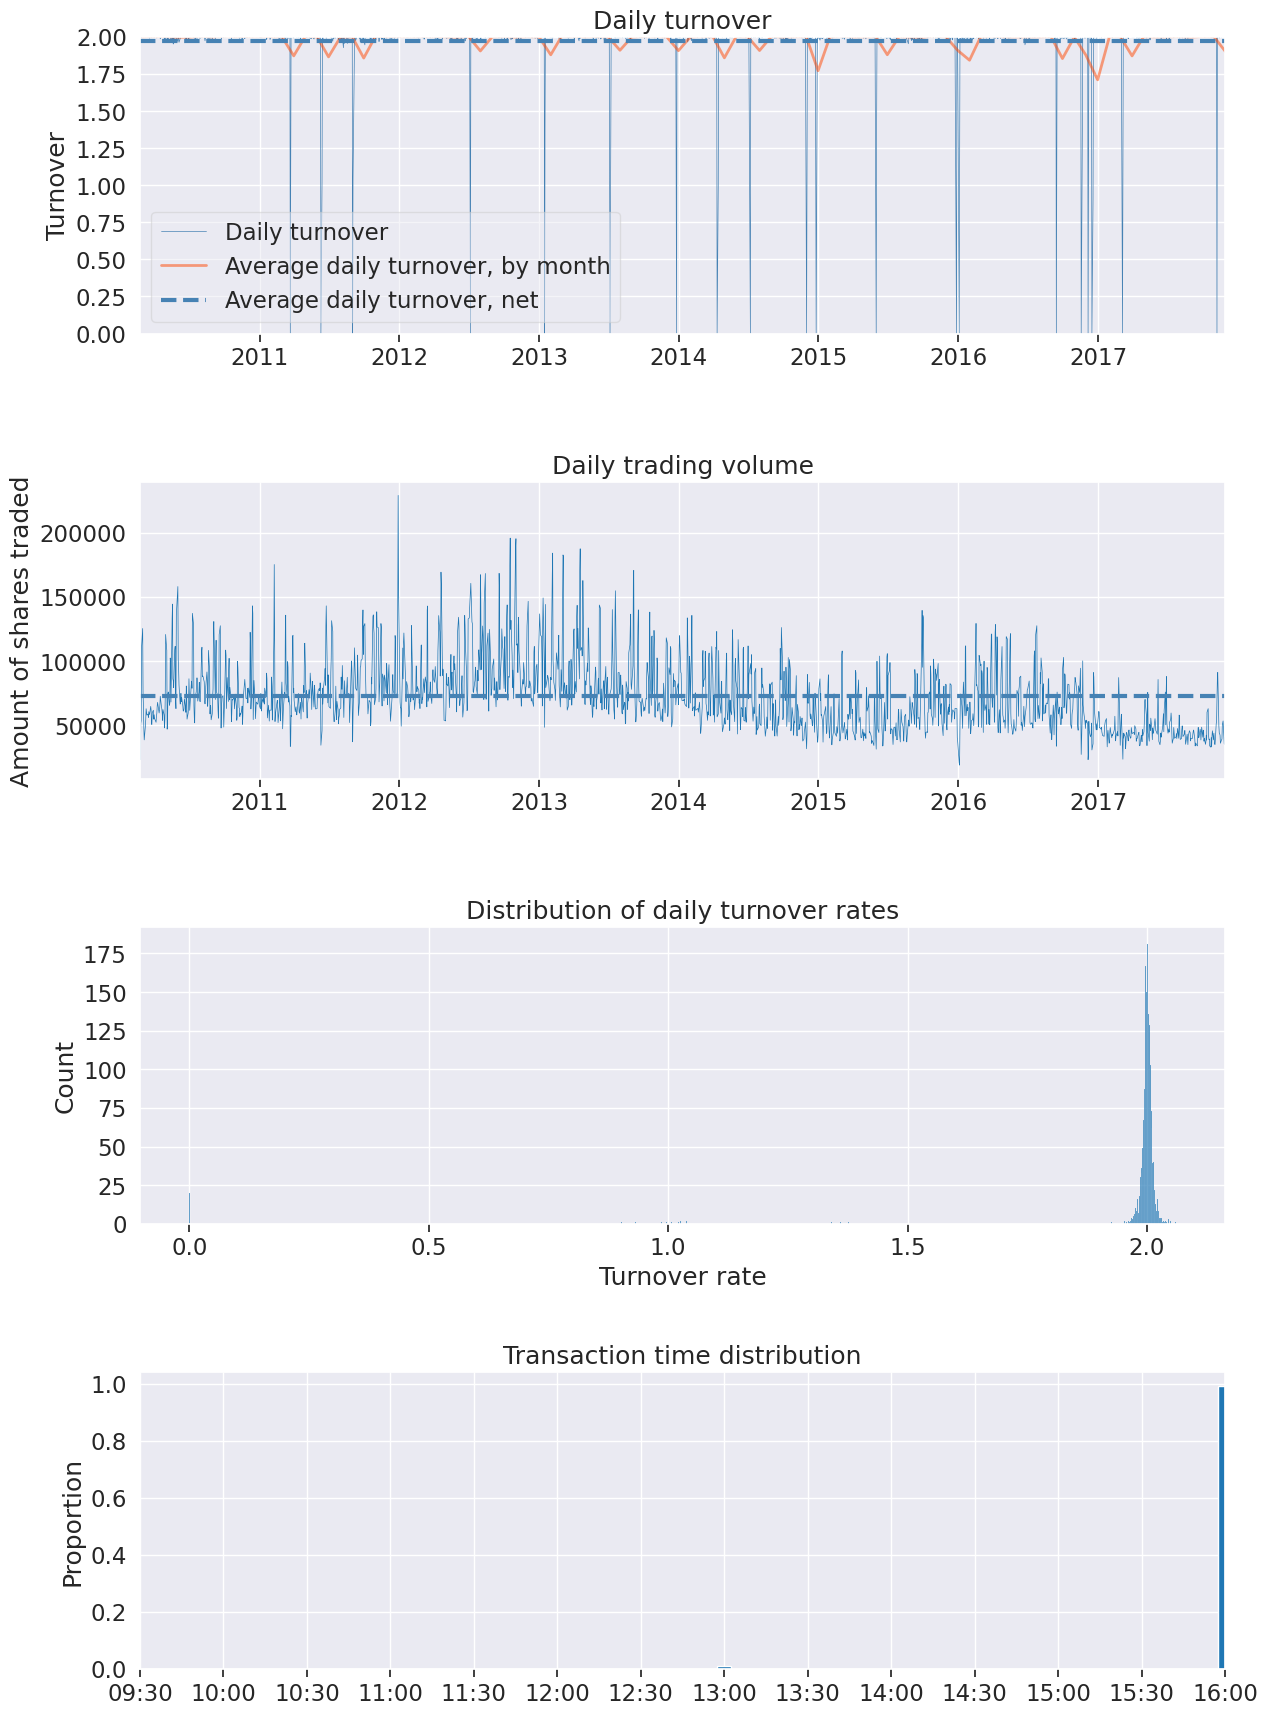

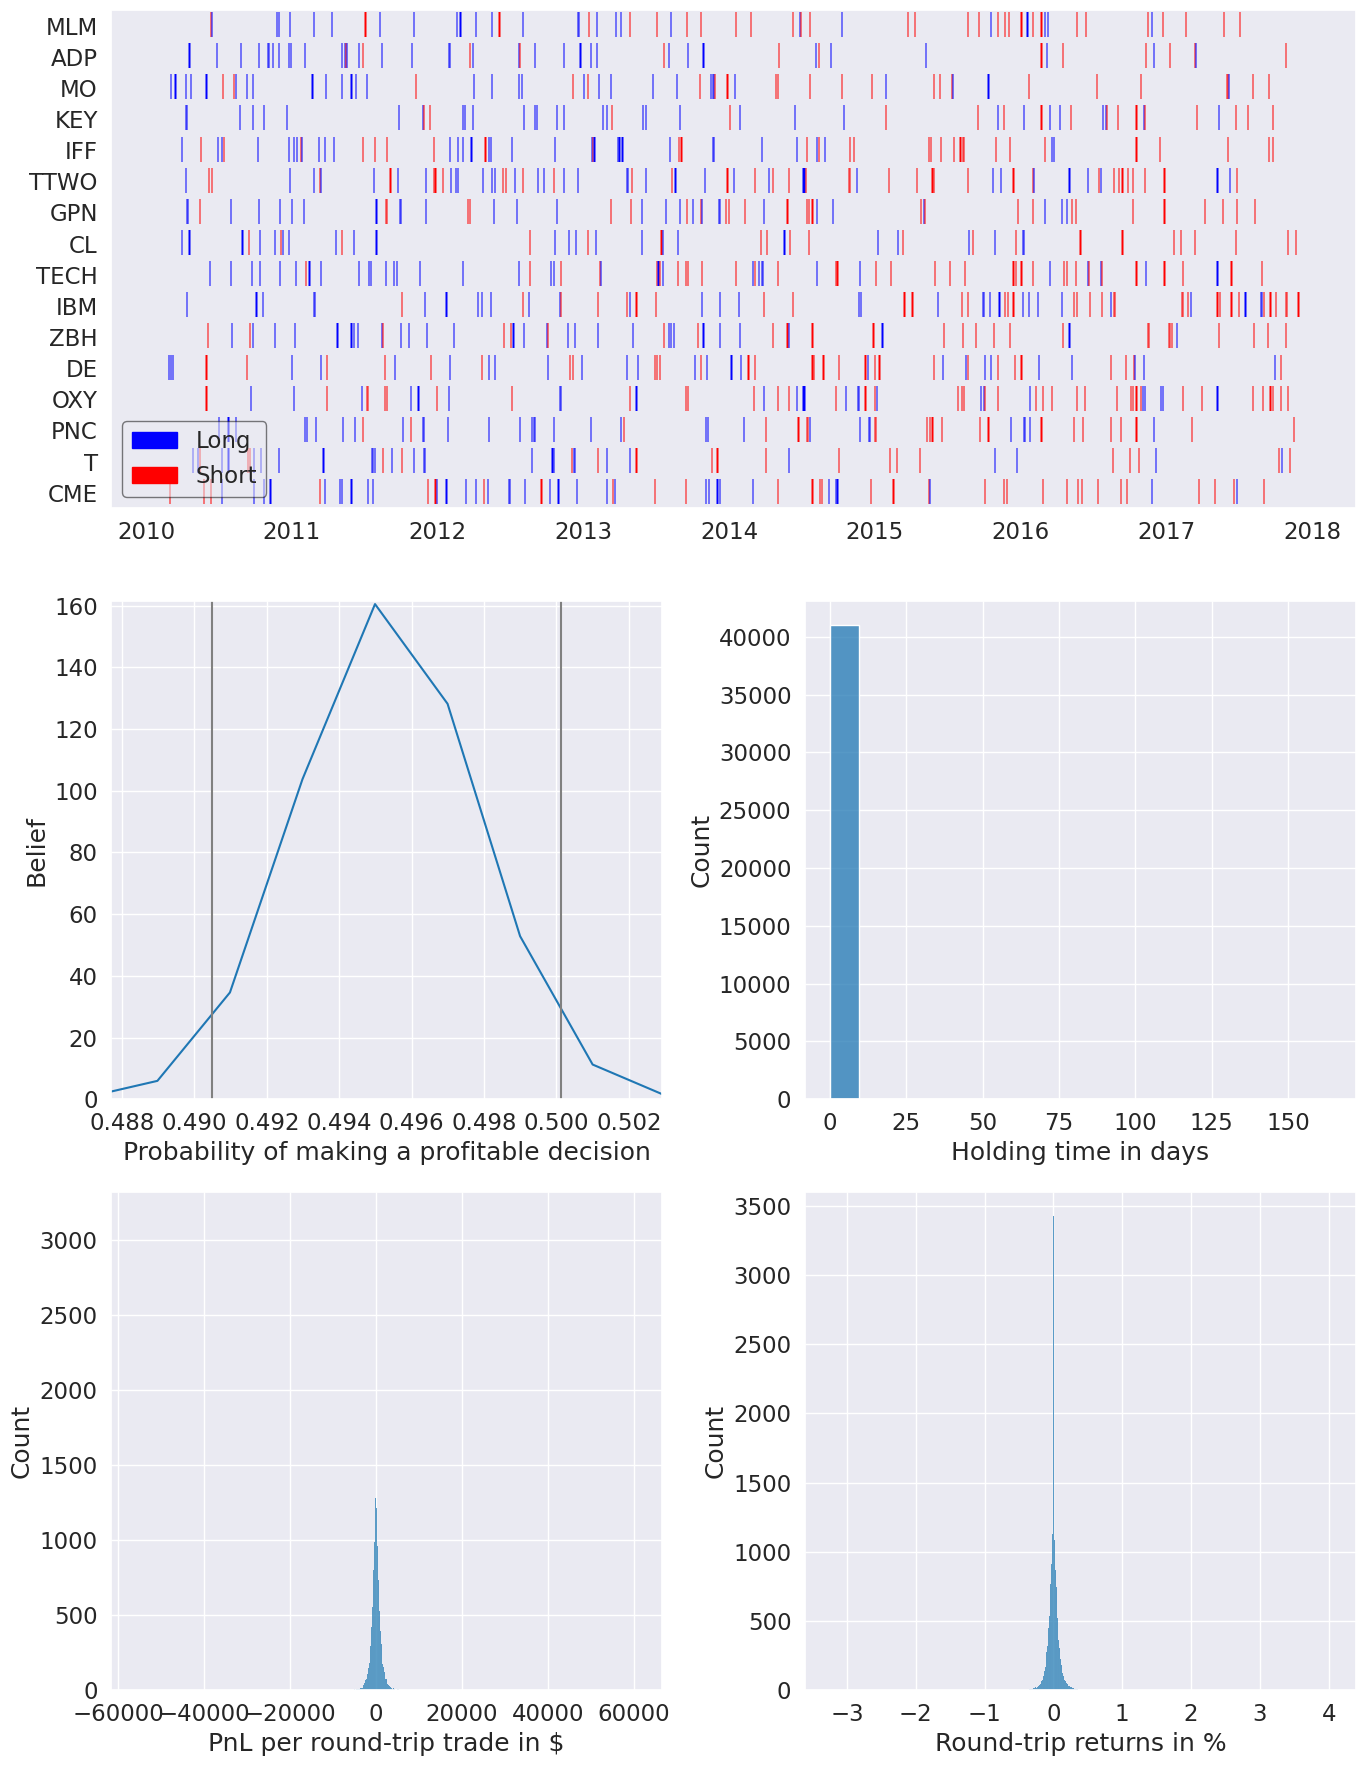

In [21]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)